# Portfolio Performance and PnL Analysis

This notebook evaluates the economic performance of the Day-Ahead trading strategy developed in the previous notebook.

The analysis focuses on gross Day-Ahead revenues, forecast-driven imbalance exposure, and key portfolio performance indicators.

In particular, this notebook covers:

- loading Day-Ahead trading results
- analysing gross trading revenues
- quantifying imbalance exposure
- estimating forecast error impact through scenario assumptions
- evaluating portfolio performance metrics
- summarising the overall trading workflow

## Configuration

In [1]:
from pathlib import Path

PROCESSED_DATA_DIR = "../data/processed"

TRADING_FILE = "../data/processed/day_ahead_trading_results.csv"

## Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Load Trading Results

The Day-Ahead trading results generated in the previous notebook are loaded for portfolio performance analysis.

The dataset contains hourly market prices, forecast generation, actual generation, Day-Ahead positions, imbalance volumes, and gross Day-Ahead revenues.

In [3]:
trading_df = pd.read_csv(
    TRADING_FILE,
    parse_dates=["datetime"]
)

trading_df.head()

,datetime,actual,forecast,price,hour,month,day_ahead_position,imbalance,absolute_imbalance,day_ahead_revenue
0,2023-10-01 00:00:00,0.0,0.0,107.81,0,10,0.0,0.0,0.0,0.0
1,2023-10-01 01:00:00,0.0,0.0,105.81,1,10,0.0,0.0,0.0,0.0
2,2023-10-01 02:00:00,0.0,0.0,104.61,2,10,0.0,0.0,0.0,0.0
3,2023-10-01 03:00:00,0.0,0.0,95.18,3,10,0.0,0.0,0.0,0.0
4,2023-10-01 04:00:00,0.0,0.0,95.18,4,10,0.0,0.0,0.0,0.0


## Data Quality Checks

Basic checks are performed to verify that the trading dataset was loaded correctly and contains no missing values.

In [ ]:
print("Rows:", len(trading_df))
print("\nMissing values:")
print(trading_df.isna().sum())

trading_df.info()

Rows: 2209

Missing values:
datetime              0
actual                0
forecast              0
price                 0
hour                  0
month                 0
day_ahead_position    0
imbalance             0
absolute_imbalance    0
day_ahead_revenue     0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2209 entries, 0 to 2208
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   datetime            2209 non-null   datetime64[ns]
 1   actual              2209 non-null   float64       
 2   forecast            2209 non-null   float64       
 3   price               2209 non-null   float64       
 4   hour                2209 non-null   int64         
 5   month               2209 non-null   int64         
 6   day_ahead_position  2209 non-null   float64       
 7   imbalance           2209 non-null   float64       
 8   absolute_imbalance  2209 non-null   float64    

## Portfolio Performance Metrics

Key performance indicators (KPIs) are calculated to summarize the overall economic performance of the simulated Day-Ahead trading strategy.

These metrics provide a concise overview of trading revenues, forecast accuracy, and portfolio efficiency.

In [ ]:
total_revenue = trading_df["day_ahead_revenue"].sum()
average_hourly_revenue = trading_df["day_ahead_revenue"].mean()
std_hourly_revenue = trading_df["day_ahead_revenue"].std()
average_absolute_imbalance = trading_df["absolute_imbalance"].mean()
total_forecast_generation = trading_df["forecast"].sum()
average_market_price = trading_df["price"].mean()

performance_df = pd.DataFrame({
    "Metric": [
        "Total Day-Ahead Revenue",
        "Average Hourly Revenue",
        "Hourly Revenue Volatility",
        "Average Absolute Imbalance",
        "Total Forecast Generation",
        "Average Market Price"
    ],
    "Value": [
        f"€{total_revenue:,.2f}",
        f"€{average_hourly_revenue:,.2f}",
        f"€{std_hourly_revenue:,.2f}",
        f"{average_absolute_imbalance:.2f} kW",
        f"{total_forecast_generation:,.0f} kWh",
        f"€{average_market_price:.2f}/MWh"
    ]
})

performance_df

,Metric,Value
0,Total Day-Ahead Revenue,"€3,744,146.91"
1,Average Hourly Revenue,"€1,694.95"
2,Hourly Revenue Volatility,"€2,986.71"
3,Average Absolute Imbalance,1.06 kW
4,Total Forecast Generation,"30,684 kWh"
5,Average Market Price,€123.84/MWh


### Portfolio Assessment

The simulated trading strategy generated substantial revenues over the analysis period while maintaining a relatively small average imbalance.

The combination of high forecasting accuracy and limited imbalance exposure suggests that the forecasting model provides a reliable basis for Day-Ahead market participation.

Overall, the strategy demonstrates that accurate renewable generation forecasts can substantially improve the quality of trading decisions and reduce operational uncertainty.

## Imbalance Cost Scenarios

The previous notebook evaluated gross Day-Ahead revenues assuming that forecast generation is fully traded at the Day-Ahead market price.

In practice, forecast errors generate imbalance volumes that are settled separately after delivery. Since actual imbalance settlement prices are not available in this project, a scenario-based approach is adopted.

Three penalty scenarios are considered to estimate the potential financial impact of forecast errors:

- **Optimistic:** imbalance cost equal to 5% of the Day-Ahead price;
- **Base Case:** imbalance cost equal to 10% of the Day-Ahead price;
- **Conservative:** imbalance cost equal to 20% of the Day-Ahead price.

In [ ]:
penalties = {
    "Optimistic (5%)": 0.05,
    "Base Case (10%)": 0.10,
    "Conservative (20%)": 0.20
}
scenario_results = []
gross_revenue = trading_df["day_ahead_revenue"].sum()

for scenario, penalty in penalties.items():
    imbalance_cost = (
        trading_df["absolute_imbalance"]
        * trading_df["price"]
        * penalty
    ).sum()

    net_revenue = gross_revenue - imbalance_cost

    scenario_results.append({
        "Scenario": scenario,
        "Gross Revenue (€)": gross_revenue,
        "Estimated Imbalance Cost (€)": imbalance_cost,
        "Estimated Net Revenue (€)": net_revenue
    })

scenario_df = pd.DataFrame(scenario_results)

In [ ]:
scenario_display = scenario_df.copy()
currency_columns = [
    "Gross Revenue (€)",
    "Estimated Imbalance Cost (€)",
    "Estimated Net Revenue (€)"
]

for col in currency_columns:
    scenario_display[col] = scenario_display[col].map(
        lambda x: f"€{x:,.2f}"
    )

scenario_display

,Scenario,Gross Revenue (€),Estimated Imbalance Cost (€),Estimated Net Revenue (€)
0,Optimistic (5%),"€3,744,146.91","€14,385.87","€3,729,761.04"
1,Base Case (10%),"€3,744,146.91","€28,771.73","€3,715,375.18"
2,Conservative (20%),"€3,744,146.91","€57,543.46","€3,686,603.44"


## Estimated Imbalance Cost

The scenario analysis evaluates how different assumptions regarding imbalance settlement costs affect the overall profitability of the trading strategy.

Although simplified, these scenarios provide a practical estimate of the financial sensitivity of renewable trading performance to forecast uncertainty.

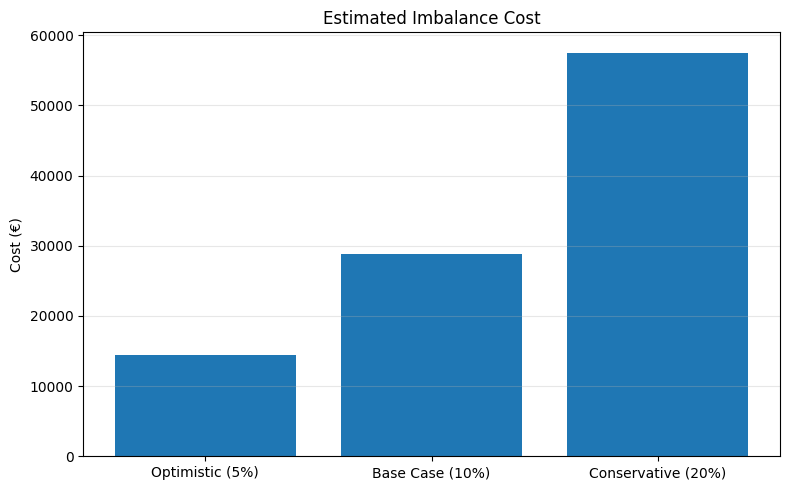

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(
    scenario_df["Scenario"],
    scenario_df["Estimated Imbalance Cost (€)"]
)
plt.title("Estimated Imbalance Cost")
plt.ylabel("Cost (€)")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### Business Insight

The scenario analysis shows that the trading strategy remains profitable under all considered imbalance cost assumptions.

Although higher imbalance penalties reduce net revenues, the financial impact remains relatively limited compared with the overall gross revenue generated by the portfolio.

These findings highlight that accurate photovoltaic generation forecasts not only improve Day-Ahead market positioning but also reduce the economic exposure associated with forecast uncertainty. Consequently, further improvements in forecasting accuracy can directly translate into more robust trading performance.

## Final Project Assessment

This project presented a complete machine learning workflow for short-term renewable energy trading.

Starting from historical Italian electricity market prices, photovoltaic generation was forecast using weather information and subsequently incorporated into a simplified Day-Ahead trading strategy.

The results demonstrate that accurate renewable generation forecasts substantially reduce imbalance exposure, support stable trading revenues, and improve the overall quality of market participation. Furthermore, the scenario analysis showed that the trading strategy remains economically robust under different imbalance cost assumptions.

Although simplified, the proposed workflow reflects the core stages of real-world renewable energy trading and provides a solid foundation for more advanced forecasting models, portfolio optimisation techniques, and risk management applications.

---

## Key Findings

This notebook evaluated the overall economic performance of the simulated Day-Ahead trading strategy and assessed its sensitivity to forecast uncertainty.

1. The trading strategy generated approximately **€3.74 million** of gross Day-Ahead revenue over the analysed period, demonstrating the economic value of accurate renewable generation forecasts.

2. Portfolio performance indicators confirmed a combination of strong trading revenues and limited imbalance exposure, reflecting the high forecasting accuracy achieved in the previous notebook.

3. A scenario-based analysis was introduced to estimate the potential financial impact of imbalance settlement costs under different penalty assumptions.

4. The trading strategy remained profitable across all analysed scenarios, indicating that the portfolio is relatively robust to moderate increases in imbalance costs.

5. The results highlight that improving photovoltaic generation forecasts not only enhances market positioning but also reduces financial exposure associated with forecast uncertainty.

This notebook concludes the end-to-end workflow developed throughout the project, from electricity market analysis and renewable generation forecasting to Day-Ahead trading strategy design and portfolio performance evaluation.